In [1]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase
from matplotlib.ticker import ScalarFormatter, FuncFormatter

from matplotlib.ticker import MaxNLocator

import matplotlib.dates as mdates


from IPython.display import display, clear_output

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [2]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/thesis").expanduser()

In [3]:
mpl.rcdefaults()
N=18
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24)   # fontsize of the figure title

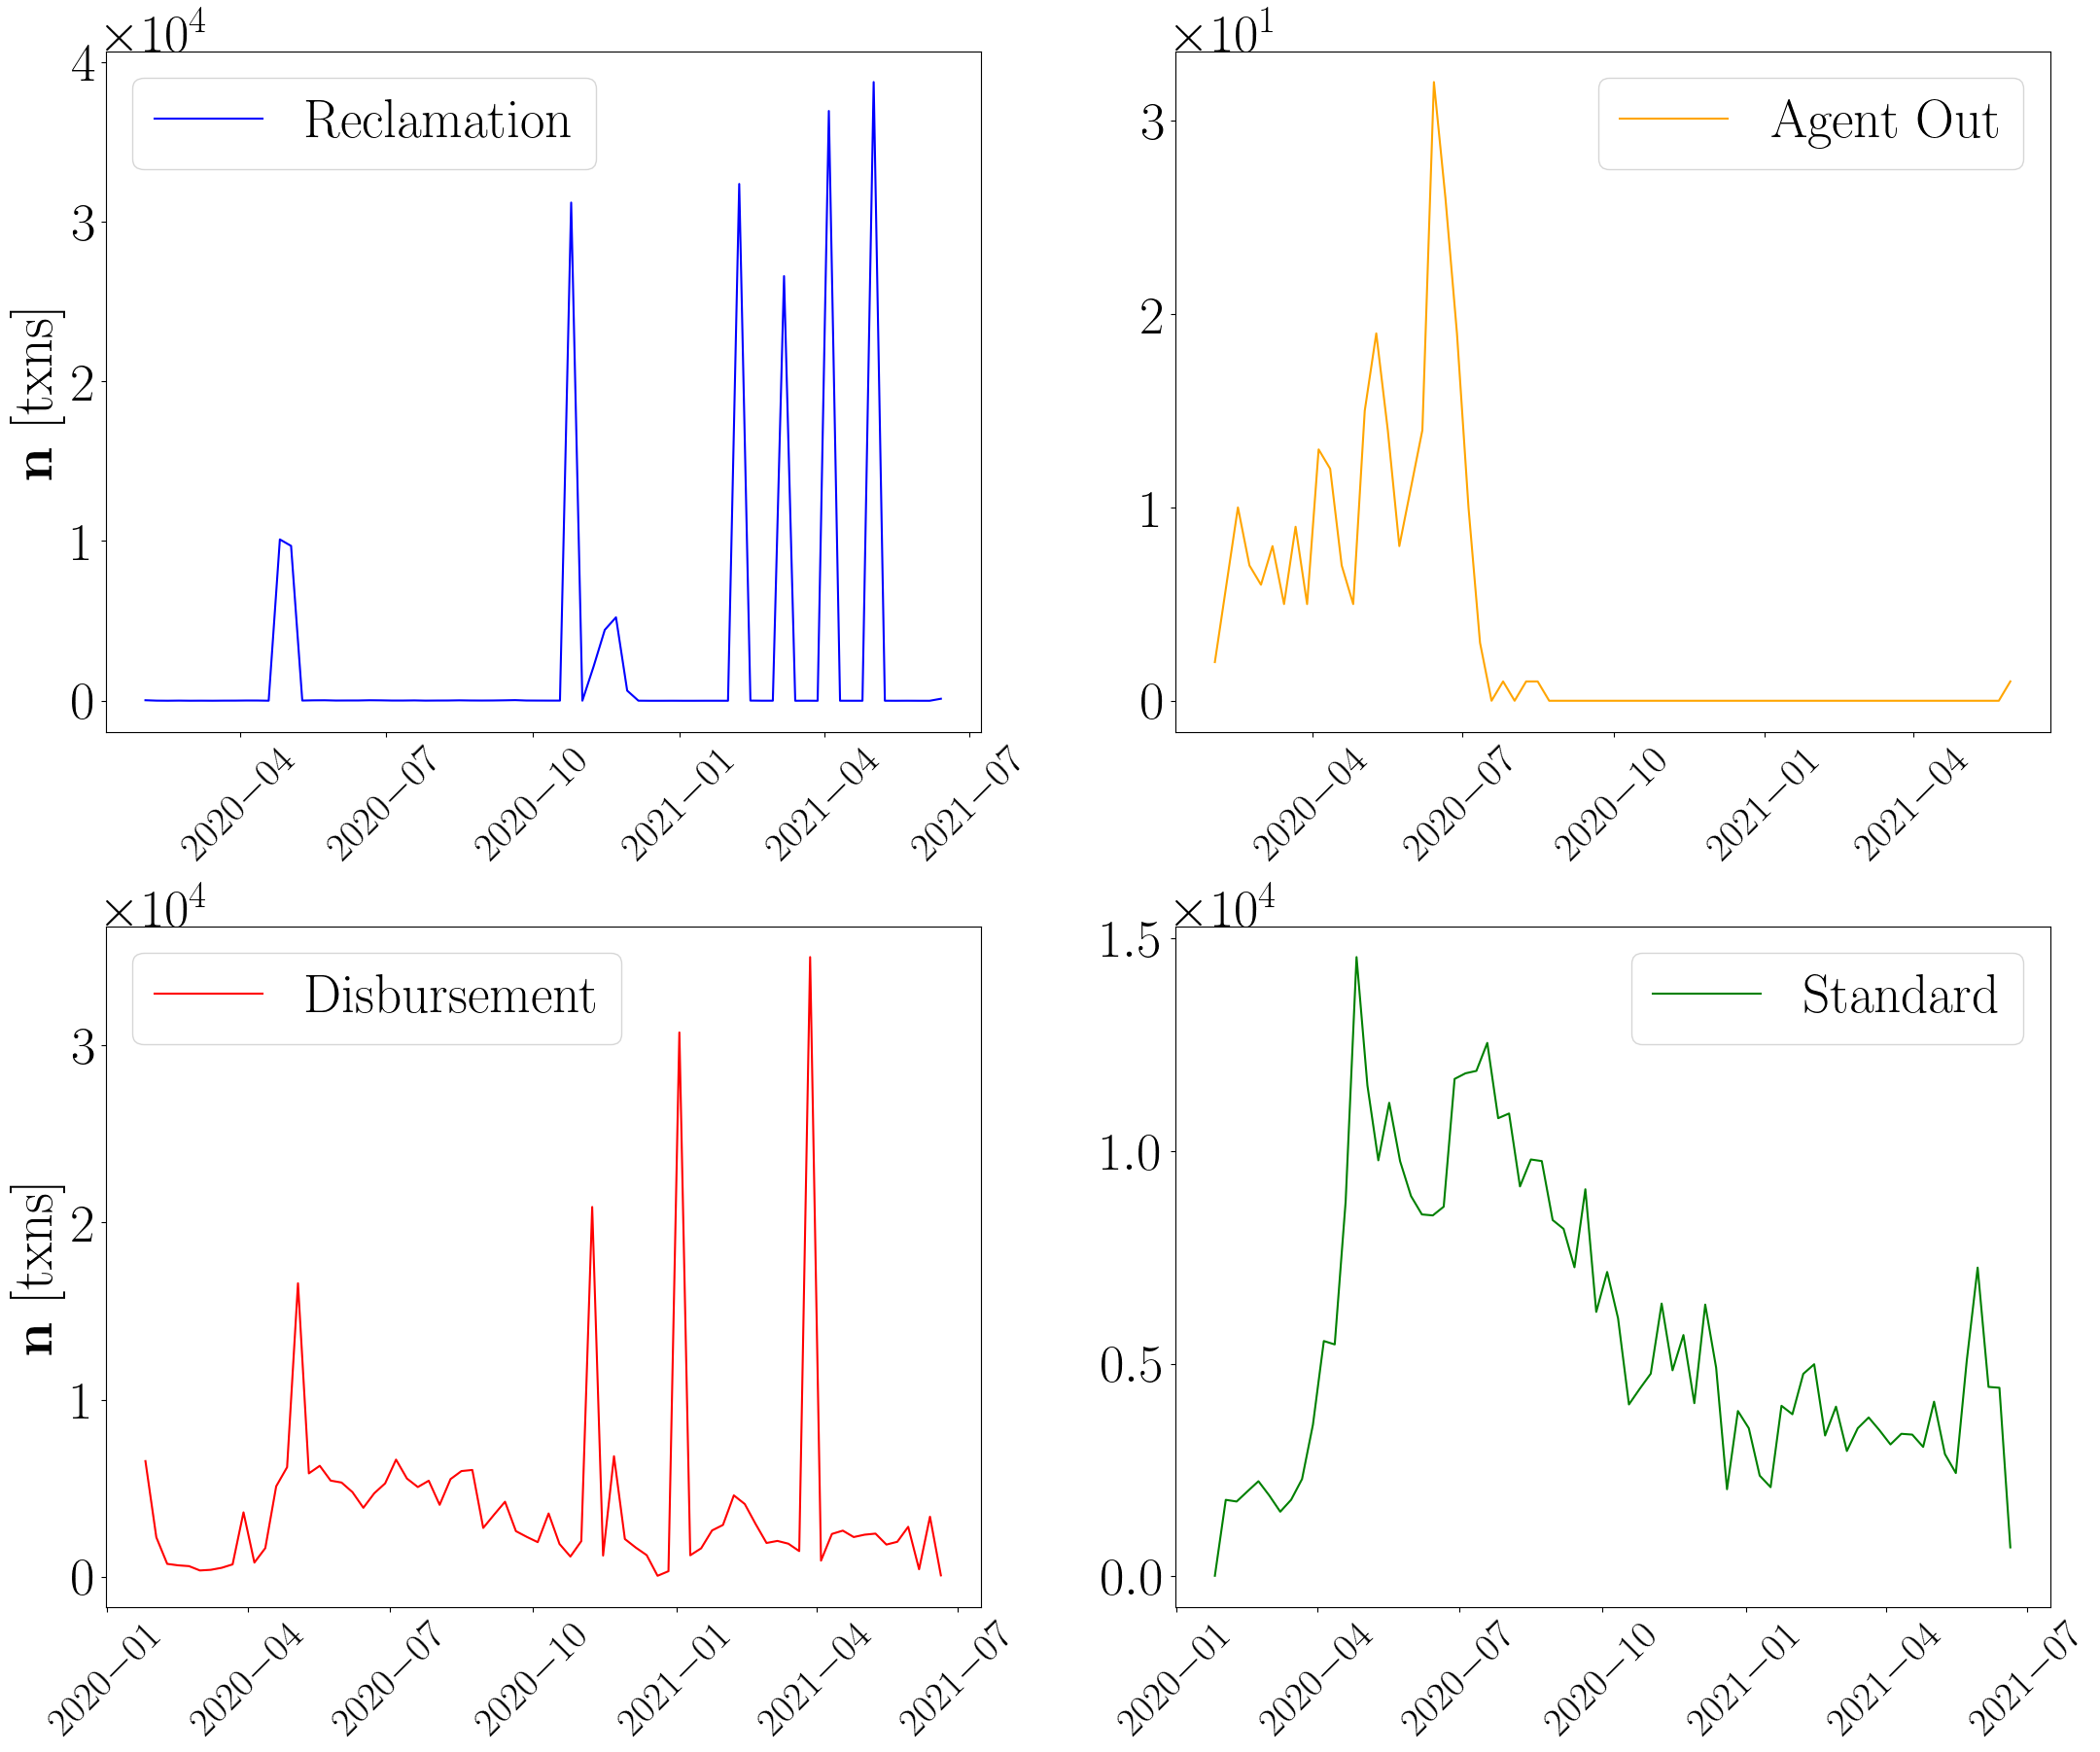

In [ ]:

# ---------------------------
# PARAMETERS
# ---------------------------
nrows, ncols = 2, 2

cbar_w, cbar_pad = 0,0
cbar_shrink = 0.         # <--- nuovo: altezza relativa
cbar_anchor = (0.5, 0.5)    # opzionale: dove “si appoggia” dentro cax (x,y)

ax_w, ax_h = 9,7
wspace, hspace = 2+cbar_w+cbar_pad, 2
left, right, bottom, top = 1.4,1.2,1.4,1.2

cbar_x_offset = 2.5
cbar_y_offset = 5

scatter_kwargs = dict(
    cmap="viridis",
    s=20,
    linewidths=0,
    rasterized = True
)



# ---------------------------
# FIGURE SIZE
# ---------------------------
fig_w = (
    left
    + ncols * (ax_w + cbar_pad + cbar_w)
    + (ncols - 1) * wspace
    + right
)
fig_h = bottom + nrows * ax_h + (nrows - 1) * hspace + top

fig = plt.figure(figsize=(fig_w, fig_h))

# ---------------------------
# DIVIDER
# ---------------------------
horizontal = [Size.Fixed(left)]
for c in range(ncols):
    horizontal.append(Size.Fixed(ax_w))
    horizontal.append(Size.Fixed(cbar_pad))
    horizontal.append(Size.Fixed(cbar_w))
    if c != ncols - 1:
        horizontal.append(Size.Fixed(wspace))
horizontal.append(Size.Fixed(right))

vertical = [Size.Fixed(bottom)]
for r in range(nrows):
    vertical.append(Size.Fixed(ax_h))
    if r != nrows - 1:
        vertical.append(Size.Fixed(hspace))
vertical.append(Size.Fixed(top))

divider = Divider(fig, (0, 0, 1, 1), horizontal, vertical)


# ---------------------------
# PLOTS
# ---------------------------
rng = np.random.default_rng(0)

axes = [None] * nrows * ncols

colors = ['r', 'g', 'b', 'orange']


#* UNFILTERED DATA 
TXDF = pickle.load(open(SARAFU_PICKLED / f"tx.pkl", "rb"))
USERS = pickle.load(open(SARAFU_PICKLED / f"users.pkl", "rb"))
types = list(TXDF.type.unique())[:4]  # keep first 4 (or remove [:4] if you always have 4)



kdex_iter = iter(range(len(types)))
kdex = 0

txdf = TXDF.copy(deep=True)
for r in range(nrows):
    for c in range(ncols):
        nx = 1 + c * 4          # ax, pad, cbar → stride 4
        ny = 1 + r * 2

        ax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=nx, ny=ny)
        )

        axes[r*ncols+c] = ax
        typo = types[kdex]
        color = colors[kdex]
        s = txdf[txdf.type == typo].resample('W', on='date').weight.count()

        ax.plot(s, color=color, label=typo.replace('_', ' ').title())

        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y')

        if kdex%2==0:
            ax.set_ylabel(r'$\textbf{n}$ [txns]')

        
        # --- Y: notazione scientifica ---
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter = sf)

        # --- X: meno tick + label più piccole ---
        loc = mdates.AutoDateLocator(minticks=6, maxticks=8)
        ax.xaxis.set_major_locator(loc)
        # ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

        ax.tick_params(axis='x',  labelsize = 30,rotation=45)
       
        ax.legend()

        kdex +=1

plt.close()
        



In [10]:
fig.savefig("/home/claudio/papers/adtxns_paper/figures/thesis/txtypes.pdf",format='pdf')


In [ ]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase



from IPython.display import display, clear_output

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [ ]:
#* SAFE NORMAL * THI SCRIPT WORKS WELL, GEENRATES GOOD QUALITY FIGURES
mpl.rcdefaults()
N=18
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24)   # fontsize of the figure title

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from matplotlib.ticker import MaxNLocator
import pickle

# ---------------------------
# PARAMETERS
# ---------------------------
nrows, ncols = 2, 2

cbar_w, cbar_pad = 0.18, 0.12
cbar_shrink = 0.82          # <--- nuovo: altezza relativa
cbar_anchor = (0.5, 0.5)    # opzionale: dove “si appoggia” dentro cax (x,y)

ax_w, ax_h = 7,7
wspace, hspace = 2+cbar_w+cbar_pad, 1.2
left, right, bottom, top = 1.4,1.2,1.4,1.2

cbar_x_offset = 2.5
cbar_y_offset = 5

scatter_kwargs = dict(
    cmap="viridis",
    s=20,
    linewidths=0,
    rasterized = True
)



# ---------------------------
# FIGURE SIZE
# ---------------------------
fig_w = (
    left
    + ncols * (ax_w + cbar_pad + cbar_w)
    + (ncols - 1) * wspace
    + right
)
fig_h = bottom + nrows * ax_h + (nrows - 1) * hspace + top

fig = plt.figure(figsize=(fig_w, fig_h))

# ---------------------------
# DIVIDER
# ---------------------------
horizontal = [Size.Fixed(left)]
for c in range(ncols):
    horizontal.append(Size.Fixed(ax_w))
    horizontal.append(Size.Fixed(cbar_pad))
    horizontal.append(Size.Fixed(cbar_w))
    if c != ncols - 1:
        horizontal.append(Size.Fixed(wspace))
horizontal.append(Size.Fixed(right))

vertical = [Size.Fixed(bottom)]
for r in range(nrows):
    vertical.append(Size.Fixed(ax_h))
    if r != nrows - 1:
        vertical.append(Size.Fixed(hspace))
vertical.append(Size.Fixed(top))

divider = Divider(fig, (0, 0, 1, 1), horizontal, vertical)

# ---------------------------
# PLOTS
# ---------------------------
rng = np.random.default_rng(0)

axes = [None] * nrows * ncols

files = [
         "/home/claudio/papers/adtxns_paper/pickled_data/sarafu/kde/sarafu__metric=in_deg-out_deg__s=NA__b=NA.pkl",
         "/home/claudio/papers/adtxns_paper/pickled_data/sarafu/kde/sarafu__metric=vol_in-vol_out__s=NA__b=NA.pkl",
        "/home/claudio/papers/adtxns_paper/pickled_data/008/kde/simulation__008__2__metric=in_deg-out_deg__s=1__b=0.75.pkl",
         "/home/claudio/papers/adtxns_paper/pickled_data/008/kde/simulation__008__2__metric=vol_in-vol_out__s=1__b=0.75.pkl",
         ]

ks = []
for f in files:
    ks.append(pickle.load(open(f, "rb")))



kdex_iter = iter(range(len(ks)))



for r in range(nrows):
    for c in range(ncols):
        nx = 1 + c * 4          # ax, pad, cbar → stride 4
        ny = 1 + r * 2

        ax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=nx, ny=ny)
        )

        axes[r*ncols+c] = ax

        # x = rng.normal(size=400)*(1+r)
        # y = rng.normal(size=400)/(c+1)
        # z = rng.normal(scale=10, size=400)*(r**2)*(c+2)

        kdex = next(kdex_iter)
        k = ks[kdex]
        x,y,z=k.x,k.y,k.z
        

        scatter_kwargs['cmap'] = 'Spectral' if kdex%2==0 else 'vanimo'
        sc = ax.scatter(x, y, c=z, **scatter_kwargs)
        # ax.set_xlabel("x")
        # ax.set_ylabel("y")

        ax.loglog()

        # colorbar axis (right of this subplot)
        cax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=nx+2, ny=ny)
        )

               
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))
        cb = fig.colorbar(sc, cax=cax, format=sf, shrink=0.85)
        # cb = fig.colorbar(
        #     sc,
        #     cax=cax,
        #     format=sf,
        #     shrink=cbar_shrink,
        #     anchor=cbar_anchor,
        # )
        # cb.locator = MaxNLocator(nbins=5)
        # cb.update_ticks()
        

        cb.set_label(None)

        ot = cb.ax

        ot.yaxis.get_offset_text().set_x(cbar_x_offset)
        ot.yaxis.get_offset_text().set_y(cbar_y_offset)


axes[0].set_xlabel('$k_{in}$')
axes[0].set_ylabel('$k_{out}$')  
axes[2].set_ylabel('$k_{out}$')    

axes[1].set_xlabel('$m_{in}$')   
axes[1].set_ylabel('$m_{out}$')
axes[3].set_ylabel('$m_{out}$') 

for ax in [axes[0],axes[2]]:
    ax.set_xlim(0.7,3*1e3)
    ax.set_ylim(0.7,3*1e3)

for ax in [axes[1],axes[3]]:
    ax.set_xlim(0.7,1e7)
    ax.set_ylim(0.7,1e7)


import numpy as np
import matplotlib.ticker as mticker

# ... dopo i tuoi set_xlim / set_ylim ...

subs = np.arange(2, 10) * 0.1  # tick minori: 2..9 dentro ogni decade

for ax in [axes[1], axes[3]]:
    # major ticks: prova a tenerne ~7
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=7))
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=7))

    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

    # minor ticks: visibili ma senza etichette
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=subs, numticks=100))
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=subs, numticks=100))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    # niente griglia (né major né minor). I tick minori restano.
    ax.grid(False)
    ax.grid(False, which="minor")

    # opzionale: rendi i minor tick più “leggeri”
    ax.tick_params(which="minor", length=3)
    ax.tick_params(which="major", length=6)



fig.savefig("buff.pdf",format='pdf')
plt.show()

